[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Speech-Interaction-Technology-Aalto-U/itsp/HEAD?urlpath=%2Fdoc%2Ftree%2FTransmission%2FCode-excited_linear_prediction_CELP.ipynb)


(content:CELP)=
# Code-excited linear prediction (CELP)


The most famous speech coding paradigm is code-excited linear prediction
(CELP). It was first invented in 1985 and is the basis of all
main-stream codecs dedicated to speech. Its most prominent variant is
the algebraic CELP, which uses an algebraic codebook to encode the noise
residual. Codecs such as
[AMR](https://en.wikipedia.org/wiki/Adaptive_Multi-Rate_audio_codec),
[EVS](https://en.wikipedia.org/wiki/Enhanced_Voice_Services),
[G.718](https://en.wikipedia.org/wiki/G.718) and
[Speex](https://en.wikipedia.org/wiki/Speex) (superseded by
[Opus](https://en.wikipedia.org/wiki/Opus_(audio_format))) are all based
on variants of CELP.


As an overview, CELP is based on a source-filter model of speech, where
[linear prediction](#content:linearprediction) is used to model the filtering
effect of the vocal tract (and other effects) and this filter is excited
by the speech source, viz. the glottal source and turbulent noise.
Typically, the [pitch or fundamental frequency
model](#content:f0) is a long-term prediction (LTP)
filter, which is just a linear predictor with a long delay. To model
noise, CELP codecs usually use a [vector
codebook](#content:vq). The codebook contribution is often
optimized with analysis-by-synthesis, where the output of different
quantizations are synthesised and the synthesised outputs are evaluated
to choose the best quantization. The evaluation uses [perceptual
weighting](Perceptual_modelling_in_speech_and_audio_coding) such that
the subjective, perceptual quality can be compared.

Since [linear prediction](#content:linearprediction) and [fundamental frequency
modelling](#content:f0) are described in detail elsewhere,
below we will discuss only overall encoder/decoder structure, perceptual
evaluation, noise modelling and analysis-by-synthesis.



![celp.png](attachments/175511854.png) 

The source-filter model of CELP codecs.


## Encoder/decoder structure

The decoder (see image on the right) very closely implements the idea of
the source-filter model (see above). The only refinement are two
multiplications with scalar gains, where the noise codebook and pitch
contribution are scaled to the desired magnitude. Observe that here we
abbreviate linear predictive coding with LPC.

The encoder and decoder typically operate in frames of 20 ms length,
which are further subdivided into 5 ms subframes. Operations described
above are thus performed on vectors whose length correspond to 5 ms,
which at a sampling-rate of 12.8 kHz corresponds to 64 samples.

The encoder (see figure on the right) first estimate the linear
predictive (LPC) model, then removes its effect from the input. In other
words, since linear prediction is IIR-filtering, we can remove the
effect from the speech signal with the corresponding FIR-filter to
obtain the LPC-residual. We can then similarly estimate the fundamental
frequency (F0) from the residual and again remove its effect to obtain
the F0-residual.

The F0-residual closely resembles white noise (following the Laplacian
distribution). We can thus quantize it with a noise-quantizer (described
below) as well as the pitch and noise gains. To evaluate the output
quality of the signal, we then decode the quantized signal and calculate
a perceptually weighted error. Since LPC-filtering is autoregressive
(IIR), it however has a non-linear effect on the output such that
quantization has a non-linear effect on the output. We therefore cannot
know which quantization is the best one without trying out *all of
them*. To get best possible performance, in theory, we should try every
possible quantization! However, in practice, we choose a group of
potentially-good quantization and find the best out of them. This is
known as the *analysis-by-synthesis* method.

Analysis-by-synthesis is a celebrated method because it enables
optimization of CELP and achieves relatively high quality. Since CELP is
arguably more efficient than competing frequency-domain codecs, and
analysis-by-synthesis enables optimization of CELPs, it is important.
However, observe that this is a brute-force method, which has an
inherent penalty in computational complexity.


![celp2.png](attachments/175511877.png)

CELP decoder structure

  

![celp3.png](attachments/175511879.png)

CELP encoder structure


## Perceptual quality evaluation

Perceptual quality in CELP codecs is evaluated with a weighted norm.
Suppose $W$ is a convolution matrix corresponding to the perceptual
weighting filter, then the weighted norm between the true and quantized
residual signals $x$ and $ \hat x $ , respectively, is

$$ d_W(x,\hat x):=\left\| W(x-\hat x)\right\|^2 = (x-\hat
x)^T W^T W (x-\hat x). $$

Though this is a quadratic form, whose minimization is simple, notice
that we consider quantized vectors, such that the minimization is an
integer-valued minimization problem, which does not have an analytic
solution.

Further, the quantized signal is the sum of noise and pitch
contributions, both multiplied with scaling factors

$$ \hat x := \gamma_{F0} x_{F0} + \gamma_{noise} x_{noise}.
$$

When estimating the F0, we can set the noise contribution to zero, such
that we minimize

$$ \arg\min_{x_{F0}}\, d_W(x,\gamma_{F0}x_{F0}):=
\arg\min_{x_{F0}}(x-\gamma_{F0}x_{F0})^T W^T W
(x-\gamma_{F0}x_{F0}). $$

To compare different pitch contributions, we further need to exclude the
gain from the problem, which is achieved by setting the derivative with
respect to $ \gamma_{F0} $ to zero (left as an exercises), which
gives the optimal gain as

$$ \gamma_{F0}^* = \frac{x^TW^T W x_{F0}}{x_{F0}^TW^T W
x_{F0}}. $$

Substituting back to the original problem, after removing constants,
yields

$$ x_{F0}^*:=\arg\min_{x_{F0}}\,
d_W(x,\gamma_{F0}^*x_{F0}):= \arg\max_{x_{F0}}
\frac{\left(x^TW^T W x_{F0}\right)^2}{x_{F0}^TW^T W x_{F0}}. $$

Observe that this equation thus evaluates the weighted correlation
between the original signal $x$ and the pitch contribution. In other
words, different F0's can be evaluated with this function and the one
with the highest correlation is chosen as the F0.

Once the F0 has been chosen, we calculate the optimal gain and subtract
it from the original residual signal, $ x':=x - \gamma_{F0}^*
x_{F0}^*. $ This F0-residual is then approximately white noise and
can be modelled with the noise codebook. Similarly as above, we assume
that the noise-gain is optimal such that the noise codebook can be
optimized with

$$ \gamma_{noise}^* = \frac{x^TW^T W x_{noise}}{x_{noise}^TW^T W
x_{noise}} $$

and

$$ x_{noise}^*:=\arg\min_{x_{noise}}\,
d_W(x',\gamma_{noise}^*x_{noise}):= \arg\max_{x_{noise}}
\frac{\left(x^TW^T W x_{noise}\right)^2}{x_{noise}^TW^T W
x_{noise}}. $$

We have thus quantized the pitch and noise contributions, but for the
two gains we have optimal values, but not optimal *quantized* values.
Again, since quantized values are not continuous, we do not have an
analytic solution but must search for the best quantization among all
possible values. The optimization problem is

$$ \arg\min_{\gamma_{F0},\gamma_{noise}}\,
d_W(x,\gamma_{F0}x_{F0}^* + \gamma_{noise}x_{noise}^*) =
\arg\min_{\gamma_{F0},\gamma_{noise}}\,(x-\gamma_{F0}x_{F0}^* -
\gamma_{noise}x_{noise}^*)^T W^T W (x-\gamma_{F0}x_{F0}^* -
\gamma_{noise}x_{noise}^*). $$

We note that the above equation is a polynomial of the two scalar gains
and all vector and matrix terms reduce to constants, such that

$$ \arg\min_{\gamma_{F0},\gamma_{noise}}\,
d_W(x,\gamma_{F0}x_{F0}^* + \gamma_{noise}x_{noise}^*) = c_0 +
\gamma_{F0}c_1 + \gamma_{F0}^2c_2 +\gamma_{noise}c_3 +
\gamma_{noise}\gamma_{F0}c_4 + \gamma_{noise}^2c_5. $$

In difference to the optimization of the residual vectors, this
optimization is computationally relatively simple such that we can
exhaustively search for the best gains. The gains are usually quantized
with 8 to 10 bits, such that this involves only 256 to 1024 polynomial
evaluations.  
The final quantized residual is then

$$ \hat x^* = \gamma_{F0}^* x_{F0}^* + \gamma_{noise}^*
x_{noise}^*. $$


## Noise modelling and algebraic coding

As mentioned above, the residual after LPC filtering and F0 modelling is
approximately stationary white noise, that is, it is constant variance
and samples are uncorrelated. We would like to quantize this
effectively. White noise signals have however no structure left, except
their probability distribution. We can assume that the residual samples
$ \xi_k $ follow the Laplacian distribution with zero mean,

$$ f(\xi_k)= C \exp\left(-\frac{\|\xi_k\|}{s}\right). $$

The joint log-likelihood is

$$ \log\prod_k f(\xi_k)= C'- \sum_k\frac{\|\xi_k\|}{s} = C' -
\frac1s \|x_{noise}\|_1, $$

where $ x_{noise}:= [\xi_1,\dotsc,\,\xi_{K}]. $ and $
\|x\|_1 $ is the 1-norm (absolute sum). In other words, if we
model constant-probability vectors $ x_{noise}, $  then that is
equivalent with modelling vectors with a constant 1-norm, $
\|x_{noise}\|_1=\text{constant}. $ We can thus build a codebook
which has constant 1-norm. For example, if we quantize to integer
values, then the absolute sum of the quantized signal is a fixed
integer.

In the simplest case, we can quantize $ x_{noise} $ to have one
signed pulse at location $k$, and otherwise all samples are zero. The
location of the pulse can be encoded with $ \log_2 K $ bits, and
the sign with one bit, such that the overall bit-consumption is $
1+\log_2 K. $ This encoding strategy can be readily extended by
adding more pulses. The bit-consumption of multi-pulse vectors however
becomes more complicated. The issue is that if apply a naive encoding
where we directly encode the position and sign of each pulse, then we
use more bits than necessary for two reasons. Firstly, if two pulses
overlap, then they must have the same sign otherwise they would cancel.
Secondly, pulses are indistinguishable, such that their ordering does
not matter, such that if we encode pulses one by one, changing their
order would give different bit-streams but the encoded signal would
remain the same. Both imply that we are using too many bits when using
such encodings for multiple pulses. Solutions exist for optimal encoding
of such multi-pulse vectors, but the algorithm becomes involved.

In any case, the outcome is that it is possible to generate
quantizations of residual signals with algorithmic methods. That is, we
have an algorithm or algebraic rule which defines all possible
quantizations and consequently, such quantization is known as algebraic
coding. The encoding can be chosen to have optimal bit-consumption for a
given number of pulses and it is thus (with loose assumptions) the best
possible quantization for the residual vector when using a fixed
bitrate. It is computationally efficient since the residual vectors are
mostly zeros, such that evaluation of the optimization function is
straightforward to calculate. It also efficient in the sense that
codebooks do not have to be stored, but can be generated on the fly by
an algorithm.

Algebraic coding is so central to CELP codecs that CELP codecs using
algebraic coding are known as algebraic CELP or ACELP. Most main stream
codecs, such as AMR, EVS and USAC use ACELP. Some codecs use also other
residual codebooks, but even then, algebraic codes are always the first
choice.


## Example: a simplified CELP encoder/decoder

The equations above fully specify how CELP chooses its pitch and noise contributions, once a perceptual weighting filter, a codebook and a target vector are given. Let's put this together into a small but genuine analysis-by-synthesis encoder/decoder, and see what it does to a short speech example.

To keep the implementation short and readable, we simplify a few things that real codecs handle more carefully:

-   We use no perceptual weighting ($W=I$ in the notation above); a real codec's weighting filter would shape the coding error towards frequencies where distortion is less audible.
-   The noise codebook is exactly the *simplest case* described above: a single signed pulse per subframe, found by brute-force search over all subframe positions.
-   LPC coefficients are estimated once per 20ms frame (not interpolated between frames, as most real codecs do) and are transmitted without quantization.
-   The adaptive-codebook (pitch) search is restricted to lags of at least one subframe (5ms, i.e. F0 below 200Hz), which avoids the extra bookkeeping needed when the pitch period is shorter than a subframe.
-   Both gains are quantized on a small, fixed grid (5 bits each) rather than the codec-specific quantizers real systems use.

None of these are fundamental limitations of CELP - they are exactly the kind of engineering refinement that separates a textbook description from a shipping codec - but the core loop below (LPC analysis, long-term and noise codebook search via the formulas above, quantization, and synthesis using the decoder's own filter memory) is the real thing.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.linalg import solve_toeplitz
from scipy.signal import lfilter
import librosa
import librosa.display
import IPython.display as ipd

filename = 'sounds/codingexample.wav'
fs, data = wavfile.read(filename)
data = data.astype(np.float64)
data = data / np.max(np.abs(data)) * 0.95  # normalize, leave a little headroom

ipd.display(ipd.Audio(data, rate=fs))

# Frame/subframe structure, matching the 20ms frames / 5ms subframes described above
frame_ms, subframe_ms = 20, 5
frame_len = int(frame_ms*fs/1000)
subframe_len = int(subframe_ms*fs/1000)
subframes_per_frame = frame_len // subframe_len
lpc_order = int(1.25*fs/1000)  # same rule of thumb as in the Linear prediction chapter

# Pitch (adaptive-codebook) lag search range. Lags shorter than one subframe
# would need the candidate excitation to be generated recursively, since it
# would overlap the subframe currently being predicted; we avoid that extra
# bookkeeping by requiring lag >= subframe_len.
lag_min = subframe_len            # 5ms, i.e. F0 <= 200Hz
lag_max = int(fs/80)              # F0 >= 80Hz, matching the range used throughout this book

# Small fixed grids for quantizing the two gains (5 bits each)
pitch_gain_levels = np.linspace(0.0, 1.2, 32)
noise_gain_levels = np.geomspace(1e-3, 2.0, 32)


In [2]:
n_frames = len(data)//frame_len
data = data[:n_frames*frame_len]

excitation_history = np.zeros(lag_max + frame_len)  # the adaptive codebook
synth_state = np.zeros(lpc_order)                    # LPC synthesis filter memory

decoded = np.zeros(len(data))
bits_used = 0
bits_per_subframe = 8 + 5 + 7 + 1 + 5  # lag, pitch gain, pulse position, pulse sign, noise gain

for f in range(n_frames):
    frame = data[f*frame_len:(f+1)*frame_len]

    # -- LPC analysis (same convention as in the Linear prediction chapter) ---
    windowed = frame * np.hanning(frame_len)
    autocorr = np.correlate(windowed, windowed, mode='full')[frame_len-1:frame_len+lpc_order]
    autocorr[0] *= 1.0001  # tiny regularisation to keep the Toeplitz system well-conditioned
    b = np.zeros(lpc_order+1); b[0] = 1.0
    a = solve_toeplitz(autocorr, b)
    a = a / a[0]  # A(z) = 1 + a_1 z^-1 + ... + a_p z^-p

    for s in range(subframes_per_frame):
        start = f*frame_len + s*subframe_len
        target = data[start:start+subframe_len]

        # LPC residual of this subframe, using the true past samples as filter memory
        ctx = data[max(0, start-lpc_order):start]
        ctx = np.concatenate((np.zeros(lpc_order-len(ctx)), ctx))
        x = lfilter(a, [1.0], np.concatenate((ctx, target)))[lpc_order:]

        # --- long-term (pitch) prediction: x_F0^*, argmax over candidate lags T ---
        scores = []
        for T in range(lag_min, lag_max+1):
            cand = excitation_history[-T:len(excitation_history)-T+subframe_len]
            scores.append(np.dot(x, cand)**2 / (np.dot(cand, cand) + 1e-9))
        best_T = lag_min + int(np.argmax(scores))
        x_f0 = excitation_history[-best_T:len(excitation_history)-best_T+subframe_len]

        gain_f0 = np.dot(x, x_f0) / (np.dot(x_f0, x_f0) + 1e-9)               # gamma_F0^*
        gain_f0 = pitch_gain_levels[np.argmin(np.abs(pitch_gain_levels - gain_f0))]
        x_prime = x - gain_f0 * x_f0                                          # F0-residual

        # --- noise codebook: simplest case, one signed pulse per subframe ---
        pulse_pos = int(np.argmax(x_prime**2))
        pulse_sign = np.sign(x_prime[pulse_pos]) or 1.0
        x_noise = np.zeros(subframe_len)
        x_noise[pulse_pos] = pulse_sign

        gain_noise = x_prime[pulse_pos] * pulse_sign                          # gamma_noise^*
        gain_noise = noise_gain_levels[np.argmin(np.abs(noise_gain_levels - gain_noise))]

        # --- quantized excitation and reconstruction, x_hat^* ---
        excitation = gain_f0*x_f0 + gain_noise*x_noise
        excitation_history = np.concatenate((excitation_history[subframe_len:], excitation))

        synth_out, synth_state = lfilter([1.0], a, excitation, zi=synth_state)
        decoded[start:start+subframe_len] = synth_out

        bits_used += bits_per_subframe

decoded = np.clip(decoded, -1.0, 1.0)


In [3]:
duration_s = len(data)/fs
bitrate_kbps = bits_used/duration_s/1000
print(f"Encoded {duration_s:.2f}s of speech at {bitrate_kbps:.1f} kbit/s "
      f"(excluding the LPC coefficients themselves, which we did not quantize)")


Encoded 3.56s of speech at 5.2 kbit/s (excluding the LPC coefficients themselves, which we did not quantize)


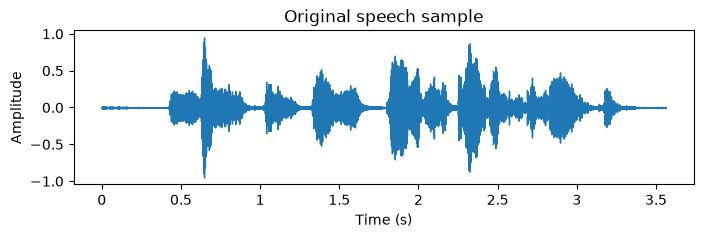

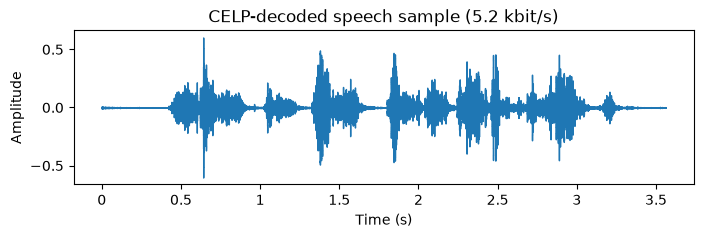

In [4]:
data_f = data.astype(np.float32)
decoded_f = decoded.astype(np.float32)

plt.figure(figsize=(8,2))
librosa.display.waveshow(data_f, sr=fs)
plt.title("Original speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(data_f, rate=fs))

plt.figure(figsize=(8,2))
librosa.display.waveshow(decoded_f, sr=fs)
plt.title(f"CELP-decoded speech sample ({bitrate_kbps:.1f} kbit/s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(decoded_f, rate=fs))


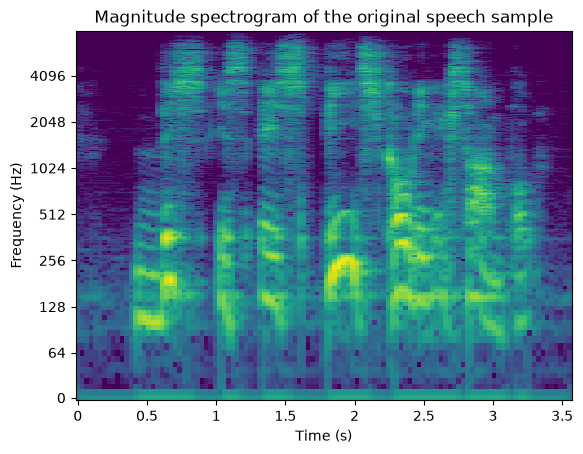

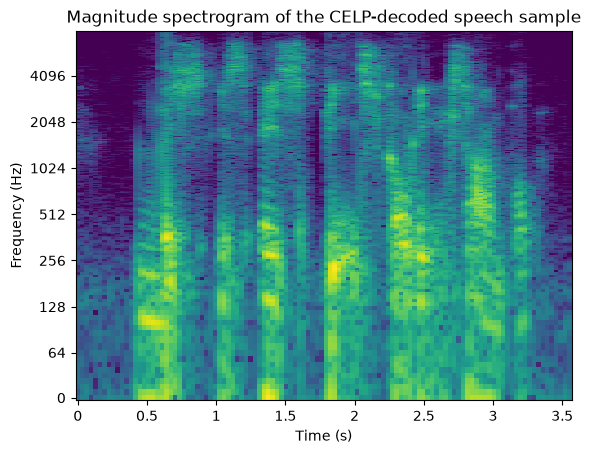

In [5]:
mag_original = librosa.amplitude_to_db(np.abs(librosa.stft(data_f)), ref=np.max)
mag_decoded = librosa.amplitude_to_db(np.abs(librosa.stft(decoded_f)), ref=np.max)

librosa.display.specshow(mag_original, y_axis="log", x_axis="time", sr=fs, cmap="viridis")
plt.title("Magnitude spectrogram of the original speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

librosa.display.specshow(mag_decoded, y_axis="log", x_axis="time", sr=fs, cmap="viridis")
plt.title("Magnitude spectrogram of the CELP-decoded speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


At roughly 5 kbit/s - lower than most deployed narrowband codecs, which typically run in the 6 to 24 kbit/s range for comparable quality - the decoded signal is clearly rougher than the original: the fine harmonic detail visible as horizontal striping in the original spectrogram is largely replaced by broadband noise, since a single pulse per 5ms subframe is a coarse way to represent the F0-residual, and we did not use perceptual weighting to spend that coarseness where it matters least. Still, the overall energy envelope, formant structure and pitch pulses are clearly preserved, which is exactly what the source-filter model and analysis-by-synthesis loop above are designed to capture. Real codecs recover much of that lost quality by using multiple pulses per subframe, interpolating LPC coefficients between frames, and shaping the coding error with a proper perceptual weighting filter - at the cost of a more involved encoder.

## Comparison to standardized codecs

Our from-scratch decoder above illustrates the core CELP idea, but it leaves out most of the engineering that separates a textbook example from a codec people actually use: multi-pulse/algebraic codebooks instead of a single pulse, perceptual weighting, LPC interpolation between frames, and careful bit-exact quantization of every parameter. Three standardized codecs that a speech engineer will run into constantly are worth knowing:

-   **Opus** ([RFC 6716](https://www.rfc-editor.org/rfc/rfc6716), standardized in 2012) combines a CELP-family speech layer (SILK, itself LPC- and LTP-based like the codec above) with an MDCT-based music layer (CELT), switching between them adaptively. It is free and open, and is the codec behind WebRTC, Discord, and most browser-based calling.
-   **AMR-NB/AMR-WB** (3GPP TS 26.090, standardized in 1999 / TS 26.190, standardized in 2001) is the ACELP codec that has carried 2G/3G/VoLTE voice calls for decades, and is structurally the closest of the three to the encoder/decoder described in this chapter. These three standards span 15 years of active codec development (1999-2014), which is worth keeping in mind when comparing them below: EVS benefits from over a decade of additional refinement (better entropy coding, more elaborate codebooks, and a lot of accumulated engineering experience) that simply wasn't available when AMR-WB was designed.
-   **EVS** (3GPP TS 26.445, standardized in 2014) is the modern successor to AMR-WB used in VoLTE/5G HD voice, combining ACELP with MDCT-based coding to cover a wider range of bitrates and bandwidths.

> **Technical notes:** Opus can be produced directly in this notebook, since its reference encoder (`libopus`) ships as part of FFmpeg and a static FFmpeg binary is available as a pip package - no system-level install required. AMR and EVS don't have such a convenient pip-installable encoder; producing them means compiling the official reference source code yourself. We did exactly that in a scratch folder outside this repository, at a bitrate comparable to the examples above, and the two decoded files are included as static audio (`sounds/codingexample_amrwb.wav`, `sounds/codingexample_evs.wav`) so they can be compared directly below. Interested readers can reproduce this with the same links:

-   **AMR**: [pschatzmann/codec-amr](https://github.com/pschatzmann/codec-amr) packages the official 3GPP AMR-NB/AMR-WB reference source behind a small C++ API (`AMRNB`/`AMRWB`), with a plain CMake build that also works outside of its primary Arduino target. Note that the repository itself flags the licensing status of the underlying 3GPP reference code as unclear, so check that it fits your use case before relying on it. Our static example used the lowest AMR-WB mode (6.60 kbit/s nominal).
-   **EVS**: the authoritative source is the floating-point ANSI-C reference software distributed with [3GPP TS 26.443](https://www.3gpp.org/dynareport/26443.htm) (also mirrored on GitHub, e.g. [wanglihe/3gpp-evs](https://github.com/wanglihe/3gpp-evs)); it builds with a single `make` and produces the `EVS_cod`/`EVS_dec` command-line encoder/decoder pair, operating on headerless 16-bit PCM at the bitrates and sampling rates listed in TS 26.443. Our static example used the 7.2 kbit/s EVS primary mode.


In [6]:
import os
import subprocess
import tempfile
import imageio_ffmpeg

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
opus_bitrate_kbps = 6  # comparable to the ~5 kbit/s simplified CELP example above

with tempfile.TemporaryDirectory() as tmp:
    opus_path = os.path.join(tmp, "coded.opus")
    opus_wav_path = os.path.join(tmp, "coded.wav")

    subprocess.run([ffmpeg_exe, "-y", "-i", filename,
                     "-c:a", "libopus", "-b:a", f"{opus_bitrate_kbps}k", "-application", "voip",
                     opus_path], check=True, capture_output=True)
    subprocess.run([ffmpeg_exe, "-y", "-i", opus_path, "-ar", str(fs), opus_wav_path],
                    check=True, capture_output=True)

    opus_bytes = os.path.getsize(opus_path)
    _, opus_decoded = wavfile.read(opus_wav_path)

opus_decoded = opus_decoded.astype(np.float32) / 32768.0
opus_actual_kbps = opus_bytes*8/duration_s/1000
print(f"Opus (libopus via FFmpeg) encoded the same {duration_s:.2f}s example into "
      f"{opus_bytes} bytes ({opus_actual_kbps:.2f} kbit/s)")


Opus (libopus via FFmpeg) encoded the same 3.56s example into 2881 bytes (6.47 kbit/s)


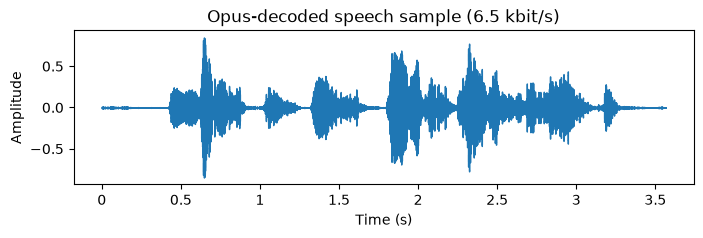

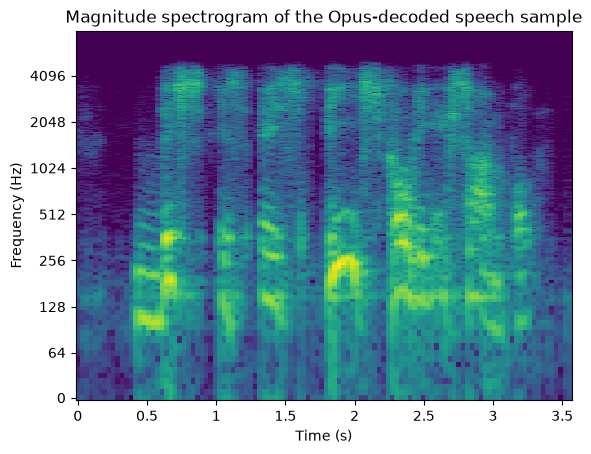

In [7]:
plt.figure(figsize=(8,2))
librosa.display.waveshow(opus_decoded, sr=fs)
plt.title(f"Opus-decoded speech sample ({opus_actual_kbps:.1f} kbit/s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(opus_decoded, rate=fs))

mag_opus = librosa.amplitude_to_db(np.abs(librosa.stft(opus_decoded)), ref=np.max)
librosa.display.specshow(mag_opus, y_axis="log", x_axis="time", sr=fs, cmap="viridis")
plt.title("Magnitude spectrogram of the Opus-decoded speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


### AMR-WB and EVS (static examples)

Unlike Opus above, these two were **not** produced live in this notebook - doing so would mean compiling the reference C source shown in the links above as part of the book build. Instead we ran the same speech example through both reference encoders/decoders externally, at a bitrate comparable to the CELP and Opus examples, and simply load the resulting audio here.

#### A naive first attempt

Let's start the way you naturally would: ask AI to feed the same sample used throughout this notebook into the AMR-WB reference encoder/decoder.

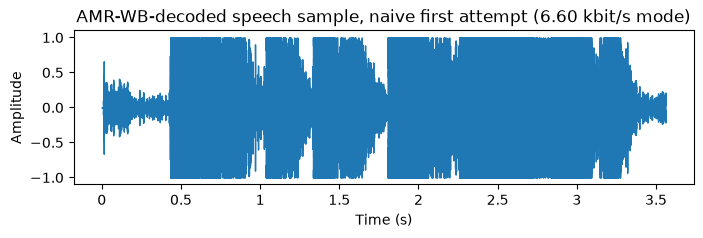

In [8]:
amrwb_broken_fs, amrwb_broken_decoded = wavfile.read('sounds/codingexample_amrwb_clipped.wav')
amrwb_broken_decoded = amrwb_broken_decoded.astype(np.float32) / 32768.0

plt.figure(figsize=(8,2))
librosa.display.waveshow(amrwb_broken_decoded, sr=amrwb_broken_fs)
plt.title("AMR-WB-decoded speech sample, naive first attempt (6.60 kbit/s mode)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(amrwb_broken_decoded, rate=amrwb_broken_fs))


**Question:** Listen to the audio and look at the waveform above. How does it sound? Does it look like it should?

*(Take a moment to think about it before reading on.)*

#### What's going wrong

Those flat tops are clipping: a look at the raw samples shows the decoded signal hard-saturating at exactly the int16 limits ($-32768$ and $32767$) on thousands of samples. This is a real characteristic of the AMR-WB reference decoder, not an artifact of our test setup - it happens at every bitrate mode, including the highest-quality one, and it's caused by the decoder's adaptive formant postfilter, which sharpens spectral peaks and can occasionally push an already near-full-scale signal past the numeric range it's stored in.

The key detail is that the sound sample, like the other examples in this notebook, is normalized close to full scale (peaks near $\pm 1$). Opus and EVS happened not to clip at that level for this particular signal, but AMR-WB's postfilter is more aggressive and does not leave itself any headroom to work with. Real telephony systems avoid this by gain-staging their audio well below 0 dBFS in the first place (a nominal reference level, not a signal that already uses the full numeric range) - exactly the safety margin our naive attempt above didn't have.

The fix follows directly from that diagnosis: encode at a safely low input level (we used roughly $-40\,\mathrm{dBFS}$, well below where the postfilter's overshoot could reach full scale even on transients), then restore the original loudness afterwards with a simple digital gain on the decoded PCM - a linear scaling that cannot introduce any new clipping, since the decoder itself never saw a signal close to its output range.

#### Fixed version

With that fix applied - encode at low level, then restore loudness digitally afterwards - the same reference decoder produces a clean result:

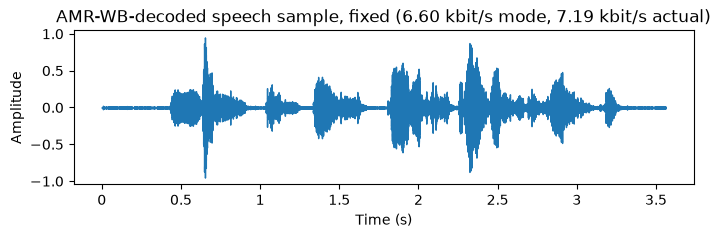

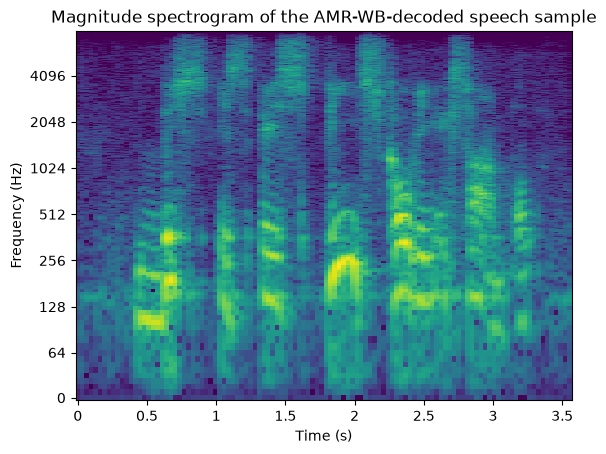

In [9]:
amrwb_fs, amrwb_decoded = wavfile.read('sounds/codingexample_amrwb.wav')
amrwb_decoded = amrwb_decoded.astype(np.float32) / 32768.0

plt.figure(figsize=(8,2))
librosa.display.waveshow(amrwb_decoded, sr=amrwb_fs)
plt.title("AMR-WB-decoded speech sample, fixed (6.60 kbit/s mode, 7.19 kbit/s actual)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(amrwb_decoded, rate=amrwb_fs))

mag_amrwb = librosa.amplitude_to_db(np.abs(librosa.stft(amrwb_decoded)), ref=np.max)
librosa.display.specshow(mag_amrwb, y_axis="log", x_axis="time", sr=amrwb_fs, cmap="viridis")
plt.title("Magnitude spectrogram of the AMR-WB-decoded speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


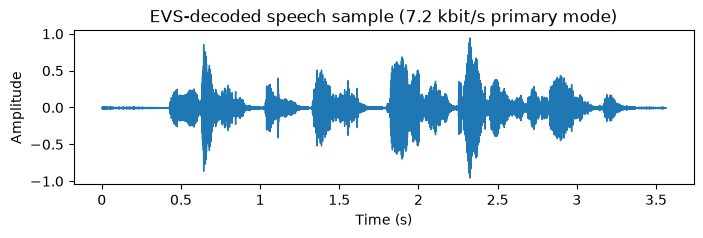

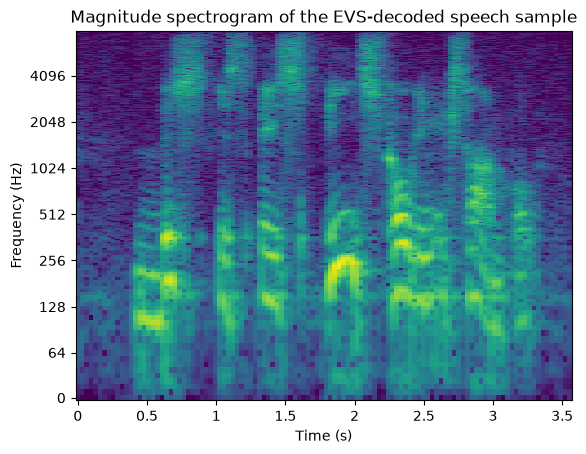

In [10]:
evs_fs, evs_decoded = wavfile.read('sounds/codingexample_evs.wav')
evs_decoded = evs_decoded.astype(np.float32) / 32768.0

plt.figure(figsize=(8,2))
librosa.display.waveshow(evs_decoded, sr=evs_fs)
plt.title("EVS-decoded speech sample (7.2 kbit/s primary mode)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(evs_decoded, rate=evs_fs))

mag_evs = librosa.amplitude_to_db(np.abs(librosa.stft(evs_decoded)), ref=np.max)
librosa.display.specshow(mag_evs, y_axis="log", x_axis="time", sr=evs_fs, cmap="viridis")
plt.title("Magnitude spectrogram of the EVS-decoded speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


Even at similar bitrates, all three standardized codecs keep noticeably more harmonic detail visible in their spectrograms than our simplified CELP decoder above - unsurprising, since Opus's SILK layer, AMR-WB and EVS all use essentially the same source-filter and analysis-by-synthesis structure introduced in this chapter, but with a proper perceptual weighting filter, richer excitation codebooks, and decades of engineering refinement that our simplified implementation deliberately left out to keep the algorithm's core ideas visible. Telling the three standardized codecs apart by eye (or by a quick listen) isn't perfectly reliable at these bitrates - distinguishing them rigorously would need a formal listening test - but any quality differences you do notice between AMR-WB, EVS and Opus are plausibly explained by the 15 years separating AMR-WB's standardization (1999/2001) from EVS's (2014), with Opus (2012) in between: later codecs benefit from more accumulated engineering experience, not just a fundamentally different algorithm. All three, regardless of vintage, clearly outperform our textbook implementation, which is exactly the point: the equations in this chapter describe the mechanism, and the engineering built on top of it is what turns that mechanism into a codec people actually use.


## Neural speech codecs

Everything above -- our own simplified encoder, Opus, AMR-WB, EVS -- shares the same blueprint: a hand-designed source-filter model, a hand-designed codebook, and analysis-by-synthesis driven by a hand-designed (or, in our case, omitted) perceptual weighting filter. The current generation of neural speech codecs keeps the overall shape of that blueprint but replaces every hand-designed piece with a learned one.

The dominant architecture (popularized by SoundStream and EnCodec) looks like this:

-   A convolutional **encoder** replaces LPC analysis, mapping the raw waveform directly to a sequence of continuous latent vectors at a much lower frame rate than the audio sample rate.
-   A **residual vector quantizer (RVQ)** replaces the codebook search. This is the closest analogue to CELP's own structure: just as we searched an adaptive codebook for the pitch contribution and then a noise codebook for what was left over, an RVQ quantizes the latent vector with a first codebook, then quantizes the *residual* of that with a second codebook, and so on for several stages -- exactly the cascaded, residual-correcting search CELP uses, just learned rather than designed.
-   A convolutional **decoder** replaces the LPC synthesis filter, reconstructing the waveform from the quantized latents.
-   Instead of a perceptually weighted norm, the whole system is trained end-to-end to minimize a mix of reconstruction and adversarial (GAN) losses, letting the network learn what "sounds right" directly from data rather than from an engineered weighting formula.

Because bits are spent on codebook indices at a fixed, known rate (no entropy coding), the bitrate of these codecs is exactly determined by the number of codebooks, the codebook size, and the frame rate -- we can compute it directly, the same way we did for our own CELP implementation above.

In [11]:
import torch
from encodec import EncodecModel
from encodec.utils import convert_audio

encodec_model = EncodecModel.encodec_model_24khz()
encodec_bandwidth_kbps = 6.0   # comparable to the other codec examples above
encodec_model.set_target_bandwidth(encodec_bandwidth_kbps)

# `data`/`fs` are the same normalized speech example used throughout this notebook
wav = torch.from_numpy(data.astype(np.float32)).unsqueeze(0)
wav = convert_audio(wav, fs, encodec_model.sample_rate, encodec_model.channels).unsqueeze(0)

with torch.no_grad():
    encoded_frames = encodec_model.encode(wav)
    codes = torch.cat([frame[0] for frame in encoded_frames], dim=-1)
    encodec_decoded = encodec_model.decode(encoded_frames).squeeze().numpy()

n_codebooks = codes.shape[1]
encodec_actual_kbps = n_codebooks*encodec_model.bits_per_codebook*encodec_model.frame_rate/1000
print(f"EnCodec used {n_codebooks} residual codebooks of {encodec_model.bits_per_codebook} bits each "
      f"at {encodec_model.frame_rate} frames/s -- exactly {encodec_actual_kbps:.1f} kbit/s")


/u/14/backstt1/unix/anaconda3/envs/itsp_new_jb2/lib/python3.14/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


EnCodec used 8 residual codebooks of 10 bits each at 75 frames/s -- exactly 6.0 kbit/s


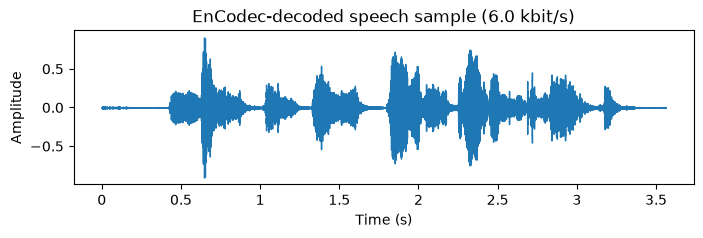

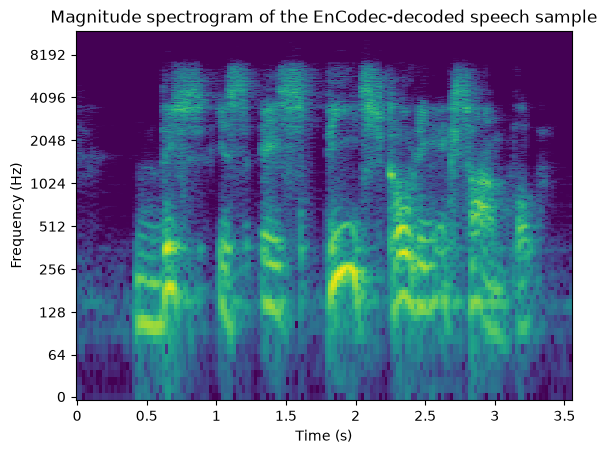

In [12]:
plt.figure(figsize=(8,2))
librosa.display.waveshow(encodec_decoded, sr=encodec_model.sample_rate)
plt.title(f"EnCodec-decoded speech sample ({encodec_actual_kbps:.1f} kbit/s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
ipd.display(ipd.Audio(encodec_decoded, rate=encodec_model.sample_rate))

mag_encodec = librosa.amplitude_to_db(np.abs(librosa.stft(encodec_decoded)), ref=np.max)
librosa.display.specshow(mag_encodec, y_axis="log", x_axis="time", sr=encodec_model.sample_rate, cmap="viridis")
plt.title("Magnitude spectrogram of the EnCodec-decoded speech sample")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


EnCodec was standardized on nothing but its own training data - unlike Opus, AMR-WB and EVS, there is no committee-approved bitstream format behind it, just a model checkpoint. That is both its strength (quality improves simply by retraining on more/better data, with no standardization process required) and its main practical drawback (a decoder from one training run generally cannot decode bits from a differently-trained encoder, unlike the standardized codecs above).

A few other neural codecs worth knowing, in roughly the order you'd encounter them:

-   **Descript Audio Codec (DAC)** ([descript/descript-audio-codec](https://github.com/descriptinc/descript-audio-codec)) uses the same RVQ+GAN recipe as EnCodec but is trained for higher fidelity, and is generally considered to outperform EnCodec at comparable bitrates -- a useful second data point if you want to compare architectures with a very similar shape but different training.
-   **Mimi** ([kyutai-labs/moshi](https://github.com/kyutai-labs/moshi)) is a streaming codec built for real-time speech-LLM pipelines: it produces both a semantic token stream (capturing linguistic content, useful as an input to a language model) and acoustic tokens (for high-quality reconstruction) from the same RVQ backbone, at extremely low latency.
-   **Lyra** ([google/lyra](https://github.com/google/lyra)) targets the same use case as our own simplified encoder and CELP itself -- real-time speech calls at very low bitrate (3 kbit/s) -- but with a learned generative decoder instead of a source-filter model, making it a direct point of comparison to the entire chapter above.

Trying either of the latter two involves noticeably more setup (downloading checkpoints from the Hugging Face Hub and, for Lyra, a C++ build), so we don't reproduce them here, but the same live-demo pattern used for EnCodec above applies equally to DAC.